# HDT2 - Modelado de un sistema real como k-armed bandit

**Dominio elegido:** optimización de la llamada a la acción (CTA, *call-to-action*) en la página de producto de un sitio de e-commerce.

Cada vez que un visitante carga la página de producto, el sistema debe decidir qué texto/diseño de botón de compra mostrarle (ej. "Comprar ahora", "Añadir al carrito", "Comprar con 1 clic"). El objetivo es maximizar la tasa de conversión sin dedicar tráfico de más a variantes que resultan malas.

## 1. Modelado formal

### 1.a Definición de los k brazos

Los brazos son un conjunto finito y predefinido de **variantes de CTA** que el equipo de producto diseñó de antemano, por ejemplo:

| Brazo | Variante |
|---|---|
| $a_1$ | "Comprar ahora" (botón rojo) |
| $a_2$ | "Añadir al carrito" (botón azul) |
| $a_3$ | "Comprar con 1 clic" (botón verde) |
| $a_4$ | "Ver oferta" (botón naranja) |
| $a_5$ | "Reservar ahora" (botón negro) |

$k=5$ en este ejemplo, pero el análisis es general para cualquier $k$ pequeño.

El conjunto de acciones es finito y discreto porque:

- Cada variante requiere trabajo de diseño/copywriting y una implementación de frontend concreta, no existe un continuo de "CTAs posibles" que el sistema pueda generar por sí mismo en tiempo real.
- El equipo de producto/legal debe aprobar cada texto y diseño antes de ponerlo en producción (tono de marca, cumplimiento de normativas de publicidad), lo que impone una lista cerrada y pequeña de variantes válidas.
- Mostrar más de un puñado de variantes simultáneamente fragmentaría el tráfico y volvería estadísticamente inviable distinguir cuál es mejor en un tiempo razonable.

Cada "tirada" del bandit corresponde a una impresión de página (una visita), y la acción es la variante de CTA que el sistema decide mostrarle a ese visitante.

### 1.b Diseño de la función de recompensa

**Qué se mide:** la recompensa $R_t$ es binaria: $R_t = 1$ si el visitante que vio la variante completa una compra en esa sesión, $R_t = 0$ si no.

**Cómo se mide:** cada visita se etiqueta con la variante mostrada y se cruza contra el evento de conversión registrado en el sistema de analítica/checkout dentro de una ventana de sesión.

**Supuesto distribucional:** la recompensa no es gaussiana, es Bernoulli: $R_t \sim \text{Bernoulli}(q_*(a))$, donde $q_*(a)$ es la tasa de conversión verdadera de la variante $a$. Argumentos:

- El resultado de cada visita es estrictamente binario (compra / no compra), no una magnitud continua con ruido aditivo simétrico.
- Una distribución gaussiana asignaría probabilidad positiva a recompensas negativas o mayores a 1, lo cual no tiene sentido en este dominio.
- El promedio muestral de recompensas Bernoulli converge a una tasa de conversión, que es exactamente la cantidad de negocio que queremos estimar y optimizar.

Si se quisiera modelar el valor monetario de la compra, ahí sí podría justificarse una distribución continua, pero para este caso se usaría la formulación binaria de conversión.

### 1.c Análisis de estacionariedad

Los valores verdaderos $q_*(a)$ no son estacionarios, cambian con el tiempo por varias razones:

- **Estacionalidad de corto plazo:** el comportamiento de compra varía por día de la semana, hora del día y campañas de marketing activas.
- **Fatiga de variante:** usuarios recurrentes se acostumbran a un CTA repetido y su efectividad decae con la exposición repetida.
- **Cambios de catálogo/competencia:** cambios de precio, stock o competidores alteran la sensibilidad del usuario al mensaje del CTA.
- **Escala temporal:** estos cambios ocurren en horizontes de días a semanas, no de milisegundos ni de años; es razonable asumir que $q_*(a)$ es aproximadamente constante dentro de una sesión de tráfico de unas pocas horas, pero deriva de forma apreciable semana a semana.

**Implicación para la regla de actualización:** con un entorno no estacionario, el promedio muestral simple pondera igual una observación de hace tres meses que una de ayer, y por lo tanto se adapta demasiado lento a la deriva. Es preferible una regla de actualización de paso constante $\alpha$ (ver sección 2.b), que da más peso a las observaciones recientes y "olvida" gradualmente el pasado distante — exactamente el comportamiento que exige un $q_*(a)$ que cambia con el tiempo.

### 1.d Restricciones de exploración

Explorar no es gratis en este dominio:

- **Costo económico directo:** cada visitante que ve una variante subóptima es una conversión potencialmente perdida; con márgenes conocidos, cada punto porcentual de tasa de conversión sacrificado por explorar se traduce directamente en ingresos no percibidos.
- **Riesgo reputacional/de marca:** una variante mal diseñada (ej. texto agresivo tipo "¡Compra ya o piérdelo!") puede dañar la percepción de marca aunque convierta bien a corto plazo; el equipo legal/de marca limita qué variantes son elegibles de antemano (ver 1.a), y a menudo exige un tope máximo de tráfico exploratorio (ej. no más de 10-20% del tráfico total en variantes no probadas).
- **Restricción regulatoria:** en jurisdicciones con leyes de protección al consumidor (ej. UE), ciertos patrones de CTA considerados "dark patterns" (presión indebida de compra) están prohibidos, lo cual reduce aún más el conjunto de brazos explorables.
- **Costo de varianza en reportes de negocio:** el equipo de finanzas necesita que la tasa de conversión agregada sea razonablemente predecible mes a mes; demasiada exploración introduce ruido que dificulta el forecasting.

Estas restricciones justifican un $\varepsilon$ pequeño y una fracción de tráfico exploratorio acotada, en vez de una exploración agresiva tipo UCB con constante alta.

## 2. Estrategia propuesta

### 2.a Estrategia de selección de acción

Se propone **$\varepsilon$-greedy con $\varepsilon = 0.1$**.

Justificación:

- Es simple de auditar y explicar a stakeholders no técnicos, algo valioso dado que hay restricciones regulatorias y de marca sobre cuánto se puede explorar.
- $\varepsilon = 0.1$ mantiene el tráfico exploratorio dentro del tope de negocio típico (~10%), sin dejar de garantizar exploración continua de las 5 variantes — necesaria porque el entorno es no estacionario y $q_*(a)$ puede reordenarse con el tiempo, por ejemplo una variante ganadora hoy puede dejar de serlo en un mes).
- Se descarta UCB porque su exploración depende de un término $c\sqrt{\ln t / N_t(a)}$ que decrece con $t$; en un entorno no estacionario esa exploración decreciente es indeseable — UCB terminaría "confiando" demasiado en estimaciones viejas de conversión que ya no reflejan la realidad actual, exactamente el problema que se busca evitar.

### 2.b Regla de actualización de estimaciones

Se usa **paso constante** $\alpha = 0.1$ en vez de promedio muestral ($1/n$):

$$Q_{n+1}(a) = Q_n(a) + \alpha \left[ R_n - Q_n(a) \right]$$

Justificación ligada a 1.c: como $q_*(a)$ deriva en escalas de días/semanas, cada nueva observación debe pesar más que una observación antigua. El paso constante produce un promedio exponencialmente ponderado que da peso $\alpha(1-\alpha)^{n-i}$ a la observación $i$-ésima, decayendo geométricamente hacia el pasado — esto hace que el sistema "olvide" activamente conversión histórica obsoleta y se adapte a la deriva del entorno, algo que el promedio muestral no puede hacer una vez que $n$ es grande.

### 2.c Ejemplo numérico

Se simulan 6 observaciones (3 por brazo) para dos variantes: $a_1$ = "Comprar ahora" y $a_2$ = "Añadir al carrito". Valor inicial neutro $Q_1(a) = 0.5$ para ambos brazos, $\alpha = 0.1$.

In [1]:
import matplotlib.pyplot as plt

alpha = 0.1
Q = {"a1": 0.5, "a2": 0.5}

observaciones = [
    (1, "a1", 1),
    (2, "a2", 0),
    (3, "a1", 0),
    (4, "a2", 1),
    (5, "a1", 1),
    (6, "a2", 0),
]

historial = {"a1": [Q["a1"]], "a2": [Q["a2"]]}
pasos = {"a1": [1], "a2": [1]}

print(f"{'t':>2} {'accion':>6} {'R':>2} {'Q_a1':>8} {'Q_a2':>8}")
print(f"{'-':>2} {'-':>6} {'-':>2} {Q['a1']:>8.4f} {Q['a2']:>8.4f}")

for t, accion, r in observaciones:
    Q[accion] = Q[accion] + alpha * (r - Q[accion])
    historial[accion].append(Q[accion])
    pasos[accion].append(len(historial[accion]))
    print(f"{t:>2} {accion:>6} {r:>2} {Q['a1']:>8.4f} {Q['a2']:>8.4f}")

 t accion  R     Q_a1     Q_a2
 -      -  -   0.5000   0.5000
 1     a1  1   0.5500   0.5000
 2     a2  0   0.5500   0.4500
 3     a1  0   0.4950   0.4500
 4     a2  1   0.4950   0.5050
 5     a1  1   0.5455   0.5050
 6     a2  0   0.5455   0.4545


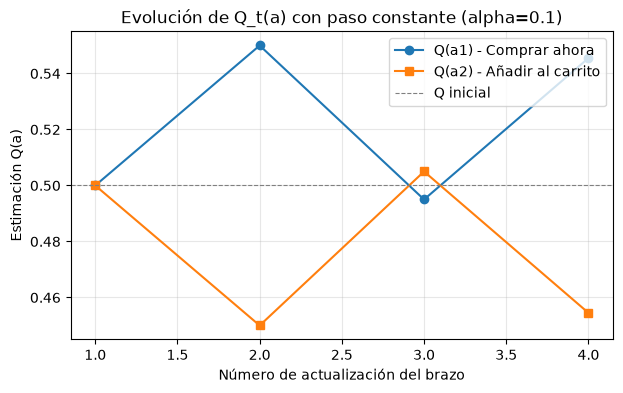

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(pasos["a1"], historial["a1"], marker="o", label="Q(a1) - Comprar ahora")
plt.plot(pasos["a2"], historial["a2"], marker="s", label="Q(a2) - Añadir al carrito")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Q inicial")
plt.xlabel("Número de actualización del brazo")
plt.ylabel("Estimación Q(a)")
plt.title("Evolución de Q_t(a) con paso constante (alpha=0.1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Lectura del resultado:**

- $a_1$ recibe recompensas $1, 0, 1$ y su estimación sube de $0.5 \to 0.55 \to 0.495 \to 0.5455$: la tendencia es al alza porque 2 de 3 observaciones fueron conversión.
- $a_2$ recibe recompensas $0, 1, 0$ y su estimación baja de $0.5 \to 0.45 \to 0.505 \to 0.4545$: la tendencia es a la baja porque 2 de 3 observaciones fueron no-conversión.
- Con solo 3 observaciones por brazo la estimación todavía no ha convergido a un valor estable; se necesitarían más tiradas para que $Q_t(a)$ se acerque a $q_*(a)$. Sin embargo el patrón ya es visible: cada actualización desplaza $Q_t(a)$ un $10\%$ de la distancia hacia la recompensa observada, lo cual es justo el comportamiento de "adaptación con memoria corta" buscado para un entorno no estacionario — si $q_*(a_2)$ mejorara dentro de un mes, la estimación lo reflejaría en pocas docenas de visitas en vez de arrastrar indefinidamente el promedio histórico completo.

## Task 2: Simulador de k-armed bandit con las tres estrategias vistas en clase: greedy puro, epsilon-greedy y UCB1

Ejecutando entorno Estacionario...
Ejecutando entorno No Estacionario...


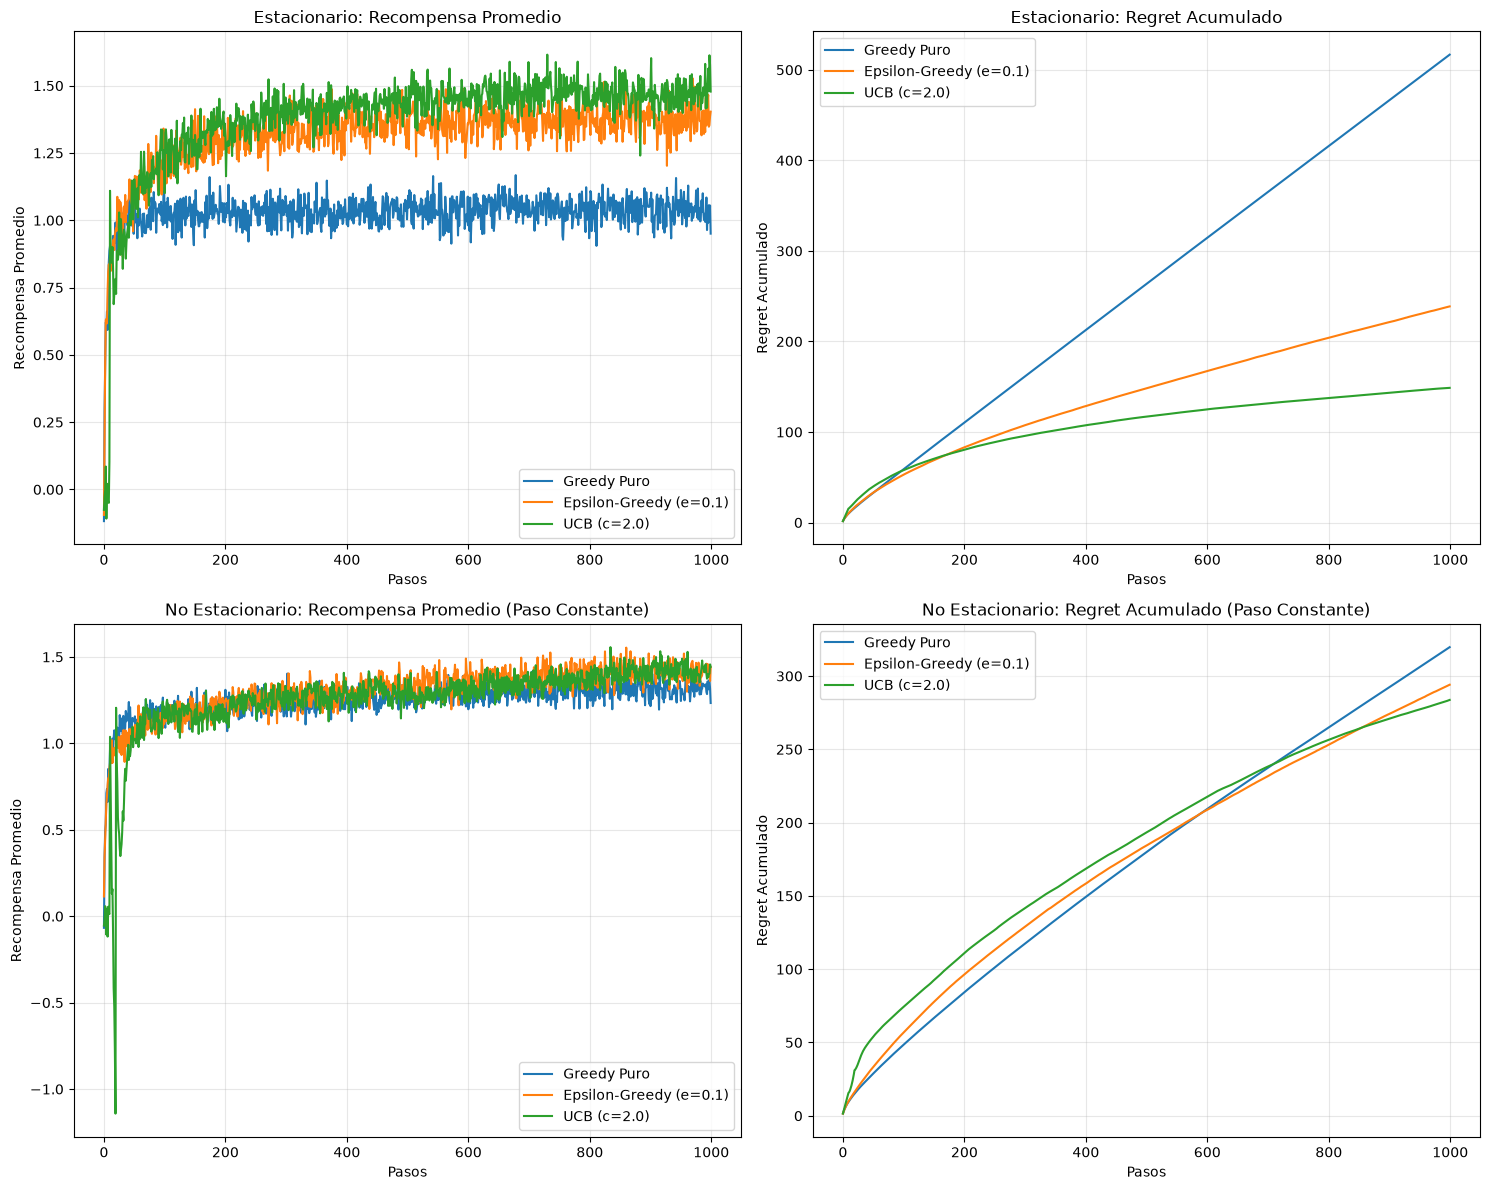

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class KArmedBandit:
    """
    Simulador de k-armed bandit con soporte para modo estacionario y no estacionario.
    """
    def __init__(self, k=10, is_non_stationary=False, perturb_freq=50, perturb_std=0.05):
        self.k = k
        self.is_non_stationary = is_non_stationary
        self.perturb_freq = perturb_freq
        self.perturb_std = perturb_std
        
        self.q_star = np.random.randn(k)
        self.step_count = 0

    def step(self, action):
        """Toma una acción, devuelve la recompensa y calcula el regret."""
        reward = np.random.randn() + self.q_star[action]
        
        expected_regret = np.max(self.q_star) - self.q_star[action]
        
        self.step_count += 1

        if self.is_non_stationary and self.step_count % self.perturb_freq == 0:
            self.q_star += np.random.normal(0, self.perturb_std, self.k)

        return reward, expected_regret

class Strategy:
    """Clase base para las estrategias del bandit."""
    def __init__(self, k, step_size=None):
        self.k = k
        self.step_size = step_size
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k)
        self.t = 0

    def update(self, action, reward):
        self.N[action] += 1
        self.t += 1

        if self.step_size is None:
            alpha = 1.0 / self.N[action]
        else:
            alpha = self.step_size

        self.Q[action] = self.Q[action] + alpha * (reward - self.Q[action])

class PureGreedy(Strategy):
    def select_action(self):
        max_q = np.max(self.Q)
        return np.random.choice(np.where(self.Q == max_q)[0])

class EpsilonGreedy(Strategy):
    def __init__(self, k, epsilon=0.1, step_size=None):
        super().__init__(k, step_size)
        self.epsilon = epsilon

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        max_q = np.max(self.Q)
        return np.random.choice(np.where(self.Q == max_q)[0])

class UCB1(Strategy):
    def __init__(self, k, c=2.0, step_size=None):
        super().__init__(k, step_size)
        self.c = c

    def select_action(self):
        if 0 in self.N:
            return np.where(self.N == 0)[0][0]
        
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        max_ucb = np.max(ucb_values)
        return np.random.choice(np.where(ucb_values == max_ucb)[0])
    
def run_experiment(strategies, k=10, is_non_stationary=False, episodes=500, steps=1000):
    avg_rewards = {name: np.zeros(steps) for name in strategies.keys()}
    cum_regrets = {name: np.zeros(steps) for name in strategies.keys()}

    for name, strategy in strategies.items():
        rewards_all = np.zeros((episodes, steps))
        regrets_all = np.zeros((episodes, steps))

        for ep in range(episodes):
            bandit = KArmedBandit(k=k, is_non_stationary=is_non_stationary)
            strategy.reset()

            for step in range(steps):
                action = strategy.select_action()
                reward, expected_regret = bandit.step(action)
                strategy.update(action, reward)

                rewards_all[ep, step] = reward
                regrets_all[ep, step] = expected_regret

        avg_rewards[name] = np.mean(rewards_all, axis=0)
        cum_regrets[name] = np.cumsum(np.mean(regrets_all, axis=0))

    return avg_rewards, cum_regrets

k = 10
eps = 500
stps = 1000

strats_stat = {
    "Greedy Puro": PureGreedy(k, step_size=None),
    "Epsilon-Greedy (e=0.1)": EpsilonGreedy(k, epsilon=0.1, step_size=None),
    "UCB (c=2.0)": UCB1(k, c=2.0, step_size=None)
}

strats_non_stat = {
    "Greedy Puro": PureGreedy(k, step_size=0.1),
    "Epsilon-Greedy (e=0.1)": EpsilonGreedy(k, epsilon=0.1, step_size=0.1),
    "UCB (c=2.0)": UCB1(k, c=2.0, step_size=0.1)
}

print("Ejecutando entorno Estacionario...")
stat_rewards, stat_regrets = run_experiment(strats_stat, k=k, is_non_stationary=False, episodes=eps, steps=stps)

print("Ejecutando entorno No Estacionario...")
nstat_rewards, nstat_regrets = run_experiment(strats_non_stat, k=k, is_non_stationary=True, episodes=eps, steps=stps)

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

for name, data in stat_rewards.items():
    axs[0, 0].plot(data, label=name)
axs[0, 0].set_title('Estacionario: Recompensa Promedio')
axs[0, 0].set_xlabel('Pasos')
axs[0, 0].set_ylabel('Recompensa Promedio')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

for name, data in stat_regrets.items():
    axs[0, 1].plot(data, label=name)
axs[0, 1].set_title('Estacionario: Regret Acumulado')
axs[0, 1].set_xlabel('Pasos')
axs[0, 1].set_ylabel('Regret Acumulado')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

for name, data in nstat_rewards.items():
    axs[1, 0].plot(data, label=name)
axs[1, 0].set_title('No Estacionario: Recompensa Promedio (Paso Constante)')
axs[1, 0].set_xlabel('Pasos')
axs[1, 0].set_ylabel('Recompensa Promedio')
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

for name, data in nstat_regrets.items():
    axs[1, 1].plot(data, label=name)
axs[1, 1].set_title('No Estacionario: Regret Acumulado (Paso Constante)')
axs[1, 1].set_xlabel('Pasos')
axs[1, 1].set_ylabel('Regret Acumulado')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### a. Analicen el comportamiento del regret acumulado de cada estrategia en el entorno estacionario. ¿La jerarquía entre estrategias coincide con lo esperado teóricamente? ¿A partir de qué paso el regret de UCB comienza a diferenciarse del de epsilon-greedy?

En la grafica superior derecha se observa  el desempeño de cada enfoque donde la estrategia de Greedy Puro tiene un crecimiento marcadamente lineal y empinado convirtiéndose en la que acumula mayor regret. Esto se debe a que al no tener un mecanismo de exploracion, frecuentemente se estanca en una acción suboptima al inicio. La estrategia epsilon greedy también muestra un crecimiento lineal pero con una pendiente mucho menor gracias a su exploración aleatoria del 10% y la estrategia UCB experimenta un aplanamiento progresivo de la curva.

Los resultados coinciden exactamente con lo esperado teoricamente ya que la teoria indica que UCB es superior a largo plazo en un entorno estacionario porque ajusta inteligentemente su exploración, garantizando que el regret crezca de forma logarítmica.

El algoritmo UCB acumula regret mas rapido que  epsilon greedy porque esta forzado a probar cada uno de los brazos al menos una vez y explora fuertemente las acciones menos vistas pero al cruzar visualmente las líneas naranja y verde en la grafica el regret de UCB comienza a diferenciarse como la mejor opción entre los pasos 150 y 200


### b. Analicen qué ocurre en el entorno no estacionario. ¿Qué estrategia se adapta mejor? ¿Cómo cambia el resultado al usar paso constante versus paso variable?

Al observar la grafica inferior derecha se nota que las lineas estan mucho mas juntas que en el escenario anterior, reflejando que el desafío es mayor para todas las estrategias debido a que el valor de las acciones cambia en el tiempo.

La estrategia que se adapta de forma excelente y robusta a este entorno es epsilon greede. La exploración constante propia del epsilon greedy le permite detectar repentinamente si una accion que solía ser mala se vuelve la optima. Greedy Puro resulta la peor a largo plazo al final de los 1000 pasos ya que al aferrarse a su primera buena impresión ignora completamente los cambios de las perturbaciones.

- Impacto de usar paso constante vs variable:

Si se usara Paso Variable el modelo daría el mismo peso estadístico a una recompensa obtenida en el paso 5 que a una del paso 900 y al usar paso constante un hiperparámetro fijo ejerce un decaimiento exponencial ponderado y esto significa que el algoritmo da alta prioridad a la realidad reciente y olvida el pasado lejano de manera activa.

Corriendo analisis de sensibilidad para Epsilon-Greedy...
Corriendo analisis de sensibilidad para UCB...


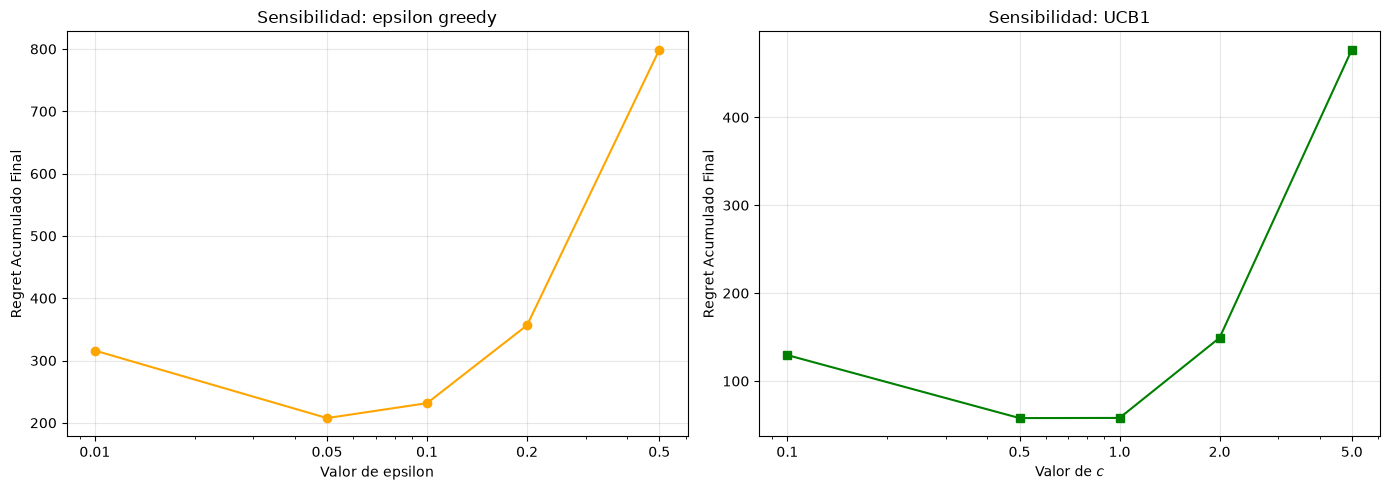

In [3]:

# Analisis de Sensibilidad

epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
cs = [0.1, 0.5, 1.0, 2.0, 5.0]

final_regrets_eps = []
final_regrets_ucb = []

print("Corriendo analisis de sensibilidad para Epsilon-Greedy...")
for e in epsilons:
    strat = {f"Epsilon ({e})": EpsilonGreedy(k, epsilon=e, step_size=None)}
    _, regrets = run_experiment(strat, k=k, is_non_stationary=False, episodes=300, steps=1000)
    final_regrets_eps.append(regrets[f"Epsilon ({e})"][-1])

print("Corriendo analisis de sensibilidad para UCB...")
for c_val in cs:
    strat = {f"UCB ({c_val})": UCB1(k, c=c_val, step_size=None)}
    _, regrets = run_experiment(strat, k=k, is_non_stationary=False, episodes=300, steps=1000)
    final_regrets_ucb.append(regrets[f"UCB ({c_val})"][-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epsilons, final_regrets_eps, marker='o', color='orange')
ax1.set_xscale('log')
ax1.set_xticks(epsilons)
ax1.set_xticklabels(epsilons)
ax1.set_title('Sensibilidad: epsilon greedy')
ax1.set_xlabel('Valor de epsilon')
ax1.set_ylabel('Regret Acumulado Final')
ax1.grid(alpha=0.3)

# Gráfica para UCB
ax2.plot(cs, final_regrets_ucb, marker='s', color='green')
ax2.set_xscale('log')
ax2.set_xticks(cs)
ax2.set_xticklabels(cs)
ax2.set_title('Sensibilidad: UCB1')
ax2.set_xlabel('Valor de $c$')
ax2.set_ylabel('Regret Acumulado Final')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ¿qué configuración específica recomendarían para el sistema real que modelaron en la entrega parcial? Justifiquen la recomendación con evidencia de sus experimentos, no solo con argumentos teóricos.

Se recomienda la implementacion de epsilon greedy con un valor de exploracion de epsilon = 0.05 y una regla de actualizacion de paso constante 

Superioridad empirica en entornos no estacionarios: En el modelado inicial establecimos que las tasas de conversion verdaderas cambian con el tiempo debido a la fatiga de la variante y factores estacionales. La evidencia de nuestra grafica de No Estacionario Regret Acumulado demostro que epsilon-greedy supera a UCB en este tipo de escenarios. Al mantener una tasa de exploracion fija, epsilon-greedy detecta de manera agil y continua cuando una variante suboptima se vuelve la ganadora debido a una perturbacion en el mercado, adaptandose mejor que el decaimiento exploratorio de UCB.

Agilidad del paso constante frente a la deriva del negocio: El uso del paso constante alfa demostro ser el mecanismo correcto para lidiar con el entorno dinamico y el experimento en el entorno no estacionario confirmo que el paso constante otorga esta agilidad geometrica previniendo que la estimacion Qt(a) se estanque como ocurriria al usar un paso variable. 

Ajuste del hiperparametro basado en el analisis de sensibilidad: la evidencia de la grafica de sensibilidad epsilon greedy muestra que el punto de mayor robustez se ubica en epsilon igual a 0.05 

Alineacion con las restricciones del dominio: Reducir empiricamente el hiperparametro de exploracion al 5 por ciento beneficia directamente al modelo de negocio planteado ya que con epsilon igual a 0.05 el algoritmo maximiza su aprendizaje reduciendo drasticamente el costo economico directo de mostrar variantes perdedoras.